# Semantic fluency preprocessing for SNAFU analysis


This notebook documents a reproducible workflow for preprocessing Italian semantic-fluency responses, deriving SNAFU-based semantic and lexical measures, and testing their associations with Picture Interpretation Test (PIT) outcomes. Input files, external lexical resources, intermediate outputs, and analysis-ready tables are named explicitly to support reuse and auditability.

In [22]:
# Core libraries and reproducibility utilities
import os
import json
import collections
from collections import defaultdict

# Data handling and numerical analysis
import pandas as pd
import numpy as np

# Text normalization and lexical resources
import unidecode
import nltk
from nltk.stem import WordNetLemmatizer
from spellchecker import SpellChecker
from Levenshtein import distance as levenshtein_distance

# Statistical analysis
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.anova import AnovaRM
from scipy.stats import spearmanr, pearsonr, shapiro, levene

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

# Progress monitoring
from tqdm import tqdm


In [23]:
# Load the raw semantic-fluency dataset using the source-file encoding
df_1 = pd.read_csv("fluenze_pit.csv", encoding='latin1')

In [24]:
# Define a local directory for NLTK resources
nltk_data_dir = os.path.expanduser('~/nltk_data')
os.makedirs(nltk_data_dir, exist_ok=True)

# Add the local NLTK directory to the search path when needed
if nltk_data_dir not in nltk.data.path:
    nltk.data.path.append(nltk_data_dir)

# Download WordNet to support lemmatization
nltk.download('wordnet', download_dir=nltk_data_dir)

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

## External resources required for reproducibility


ConceptNet 5.7.0 assertions are required to build the Italian semantic-category dictionary: https://github.com/commonsense/conceptnet5/wiki/Downloads


In [25]:
# Initialize the lemmatizer used to standardize lexical forms
lemmatizer = WordNetLemmatizer()

# Define the local path to the ConceptNet assertions file
CONCEPTNET_FILE_PATH = "/datasets/datasets/conceptnet-assertions-5.7.0.csv"

# Map study categories to their Italian semantic roots
target_categories = {
    "animals": "animale",
    "fruits": "frutta",
    "colors": "colore",
    "foods": "cibo",
    "vegetables": "verdura",
    "supermarket items": "supermercato",
    "tools": "attrezzo"
}

# Initialize the category dictionary
allWords = {cat: set() for cat in target_categories}

# Restrict ConceptNet extraction to semantic relations relevant to category membership
valid_relations = {"/r/IsA", "/r/InstanceOf", "/r/FormOf", "/r/Synonym", "/r/DefinedAs", "/r/PartOf"}

# Stream the ConceptNet file in chunks to limit memory use
chunk_size = 100000
reader = pd.read_csv(
    CONCEPTNET_FILE_PATH,
    sep='\t',
    header=None,
    usecols=[1, 2, 3],
    names=["rel", "start", "end"],
    chunksize=chunk_size
)

# Monitor ConceptNet processing progress
print("Building the category dictionary from ConceptNet...")
for chunk in tqdm(reader, desc="Processing ConceptNet"):
    # Retain selected semantic relations and Italian-language terms
    chunk = chunk[
        (chunk["rel"].isin(valid_relations)) &
        (chunk["start"].str.startswith("/c/it/")) &
        (chunk["end"].str.startswith("/c/it/"))
    ]

    # Extract Italian lexical forms from ConceptNet URIs
    chunk["start"] = chunk["start"].apply(lambda x: x.split("/")[3])
    chunk["end"] = chunk["end"].apply(lambda x: x.split("/")[3])
    chunk["rel"] = chunk["rel"].apply(lambda x: x.split("/")[2])

    # Add extracted terms to the corresponding semantic category
    for cat, root in target_categories.items():
        matches = chunk[
            chunk["start"].str.contains(root) | chunk["end"].str.contains(root)
        ]
        for _, row in matches.iterrows():
            allWords[cat].add(lemmatizer.lemmatize(row["start"]))
            allWords[cat].add(lemmatizer.lemmatize(row["end"]))

# Save the category dictionary for reuse
with open("allWords_it.json", "w", encoding="utf-8") as f:
    json.dump({k: sorted(list(v)) for k, v in allWords.items()}, f, ensure_ascii=False, indent=2)

Building category dictionary from ConceptNet...
Processing ConceptNet: 139it [00:57,  2.81it/s]/tmp/ipykernel_667/2927691789.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk["start"] = chunk["start"].apply(lambda x: x.split("/")[3])
/tmp/ipykernel_667/2927691789.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk["end"] = chunk["end"].apply(lambda x: x.split("/")[3])
/tmp/ipykernel_667/2927691789.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFra

In [26]:
# Load the ConceptNet-derived category dictionary
with open("allWords_it.json", encoding="utf-8") as f:
    allWords = json.load(f)
    allWords = {k: set(v) for k, v in allWords.items()}

# Apply spell checking to categories with dictionary coverage
semantic_categories = set(allWords.keys())

# Initialize Italian and English spell checkers
spell_it = SpellChecker(language="it")
spell_en = SpellChecker(language="en")

# Reuse the lemmatizer for lexical standardization
lemmatizer = WordNetLemmatizer()

# Track unresolved responses for transparent manual review
not_found = []

# Normalize and lemmatize each response
def preprocess(word):
    if pd.isnull(word):
        return ""
    word = str(word).lower()
    word = unidecode.unidecode(word)
    word = word.replace("-", "")
    word = lemmatizer.lemmatize(word)
    return word

# Correct responses using Levenshtein distance within the semantic dictionary
def correct_with_levenshtein(word, category_words):
    best_match = word
    best_dist = 2  # max edit distance accepted
    for candidate in category_words:
        dist = levenshtein_distance(word, candidate)
        if dist < best_dist:
            best_match = candidate
            best_dist = dist
    return best_match

# Define the final response-cleaning pipeline
def clean_item(row):
    word = preprocess(row["item"])
    category = row["listnum"]

    if category not in semantic_categories:
        return word  # clean only

    # Return the response unchanged when it is already present in the category dictionary
    if word in allWords[category]:
        return word

    # Attempt category-constrained Levenshtein correction
    corrected = correct_with_levenshtein(word, allWords[category])
    if corrected != word:
        return corrected

    # Use the Italian spell checker when dictionary correction is unavailable
    if word in spell_it:
        return word
    suggestion_it = spell_it.correction(word)
    if suggestion_it and suggestion_it in allWords[category]:
        return suggestion_it

    # Use the English spell checker as a fallback
    if word in spell_en:
        return word
    suggestion_en = spell_en.correction(word)
    if suggestion_en and suggestion_en in allWords[category]:
        return suggestion_en

    # Log unresolved terms for manual review
    not_found.append((row["item"], word, category))
    return word

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [27]:
# Apply the cleaning pipeline to all responses
df_1["item_cleaned"] = df_1.apply(clean_item, axis=1)

# Save the preprocessed dataset
df_1.to_csv("fluenze_pit_preprocessed.csv", index=False, encoding="utf-8")

# Summarize unresolved responses by category
if not_found:
    counts = collections.Counter([cat for _, _, cat in not_found])
    print("Unresolved responses by category:")
    for cat, count in counts.items():
        print(f" - {cat}: {count} words")

    # Save the unresolved-response log only when entries exist
    pd.DataFrame(not_found, columns=["original", "processed", "listnum"]).drop_duplicates().to_csv(
        "not_found.csv", index=False, encoding="utf-8"
    )
    print(f"Saved file: not_found.csv ({len(not_found)} words)")
else:
    print("No unresolved responses were identified; not_found.csv was not created.")


No words found. not_found.csv was not created.


In [28]:
df_cleaned = df_1.copy()

df_cleaned["item"] = df_cleaned["item_cleaned"]

df_cleaned.drop(columns=["item_cleaned"], inplace=True)

df_cleaned.to_csv("fluenze_pit_cleaned.csv", index=False, encoding="utf-8")

In [29]:
df_preprocessed = pd.read_csv('fluenze_pit_preprocessed.csv', encoding='utf-8')
df_preprocessed.rename(columns={'ï»¿id': 'id'}, inplace=True)
df_preprocessed.to_csv('fluenze_pit_preprocessed.csv', index=False, encoding='utf-8')

In [30]:
df_cleaned = pd.read_csv('fluenze_pit_cleaned.csv', encoding='utf-8')
df_cleaned.rename(columns={'ï»¿id': 'id'}, inplace=True)
df_cleaned.to_csv('fluenze_pit_cleaned.csv', index=False, encoding='utf-8')


# Lexical-property preparation for SNAFU analysis


## External resources required for reproducibility


SUBTLEX-IT is required to compute word-frequency estimates: https://osf.io/zg7sc/


ItAoA is required to compute age-of-acquisition estimates: https://osf.io/ctp5k/


In [31]:
# Format the ItAoA dataset using the two-column structure required by SNAFU
aoa_df = pd.read_excel("ItAoA.xlsx", sheet_name="Database")
aoa_snafu = aoa_df[["Ita_Word", "M_AoA"]].rename(columns={"Ita_Word": "word", "M_AoA": "val"})
aoa_snafu.to_csv("aoa-it_snafu.csv", index=False, encoding="utf-8-sig", sep=",", header=False)
aoa_snafu.head()

,word,val
0,abbaglio,9.36
1,abbandonato,6.68
2,abbondanza,6.96
3,abbracciare,2.84
4,abbraccio,4.20


In [32]:
# Format the SUBTLEX-IT dataset using the two-column structure required by SNAFU
freq_df = pd.read_csv("subtlex-it.csv", encoding="latin1", sep=";")
freq_cleaned = freq_df[["wordform", "freq_count"]].rename(columns={"wordform": "word", "freq_count": "val"})
freq_cleaned = freq_cleaned.dropna(subset=["word", "val"])

# Remove non-alphabetic entries from the frequency dataset
freq_cleaned = freq_cleaned[freq_cleaned["word"].str.isalpha()]
freq_cleaned.to_csv("subtlex-it_snafu.csv", index=False, encoding="utf-8-sig", sep=",", header=False)
freq_cleaned.head()

,word,val
3,non,2340479.0
4,che,2293840.0
5,è,2288908.0
6,di,2202526.0
9,un,1499479.0


## Semantic-property extraction for the color-fluency task


In [33]:
# Define input, reference, and output file paths
input_data_path = "fluenze_pit_cleaned.csv"
scheme_path = "snafu_Italian_scheme_Colors_Pupillo.csv"
freq_path = "subtlex-it_snafu.csv"
aoa_path = "aoa-it_snafu.csv"
output_csv = "snafu_colors_properties_it.csv"
output_group_csv = "snafu_colors_group_means.csv"

df_cleaned = pd.read_csv("fluenze_pit_cleaned.csv", encoding="latin1", dtype={"id": str})
print(f"Total unique IDs in df_cleaned: {df_cleaned['id'].nunique()}")

# Create the participant-to-group mapping
subject_group_df = df_cleaned[["id", "group"]].drop_duplicates()
print(f"ID→group mapping created for {len(subject_group_df)} ids")

# Load color-fluency responses with SNAFU
fluencydata = snafu.load_fluency_data(
    input_data_path,
    category="colors",
    removeNonAlphaChars=True,
    group=["MCI", "HC", "frailty"],
    hierarchical=True,
)

# Store participant identifiers processed by SNAFU as strings
subject_ids = [str(sub) for sub in fluencydata.subs]
print(f"SNAFU has included {len(subject_ids)} ids")

# Compare processed participant identifiers with the original dataset
original_ids_colors = set(df_cleaned[df_cleaned["category"] == "colors"]["id"].unique())
processed_ids = set(subject_ids)
discarded_ids = original_ids_colors - processed_ids
print(f"SNAFU has discarded {len(discarded_ids)} ids: {sorted(discarded_ids)}")

# Estimate SNAFU-derived semantic and lexical measures
cluster_switches = snafu.clusterSwitch(fluencydata.labeledlists, scheme_path, clustertype="static")
switch_rate = snafu.clusterSwitch(fluencydata.labeledlists, scheme_path, clustertype="static", switchrate=True)
cluster_size = snafu.clusterSize(fluencydata.labeledlists, scheme_path)
perseverations = snafu.perseverations(fluencydata.labeledlists)
intrusions = snafu.intrusions(fluencydata.labeledlists, scheme_path)

# Convert blank AoA and frequency values to missing values before analysis
try:
    word_freq_result = snafu.wordFrequency(fluencydata.labeledlists, data=freq_path, missing=None)
    word_freq = word_freq_result[0] if isinstance(word_freq_result, tuple) else word_freq_result
except:
    word_freq = [np.nan] * len(subject_ids)

try:
    aoa_result = snafu.ageOfAcquisition(fluencydata.labeledlists, data=aoa_path, missing=None)
    aoa = aoa_result[0] if isinstance(aoa_result, tuple) else aoa_result
except:
    aoa = [np.nan] * len(subject_ids)


results = pd.DataFrame({
    "id": subject_ids,
    "cluster_switches": cluster_switches,
    "switch_rate": switch_rate,
    "cluster_size": cluster_size,
    "perseverations": perseverations,
    "intrusions": intrusions,
    "word_freq": word_freq,
    "aoa": aoa
})

# Merge group information using participant identifiers
results = results.merge(subject_group_df, on="id", how="left")

# Save participant-level semantic and lexical measures
results["id"] = results["id"].astype(int)
results = results.sort_values("id")

for col in results.select_dtypes(include=["float", "int"]).columns:
    results[col] = results[col].round(2)

results.to_csv(output_csv, index=False, encoding="latin1")

# Compute and save group-level means
group_means = results.groupby("group").mean(numeric_only=True).reset_index()
for col in group_means.select_dtypes(include=["float", "int"]).columns:
    group_means[col] = group_means[col].round(2)

group_means.to_csv(output_group_csv, index=False, encoding="latin1")

Total unique IDs in df_cleaned: 110
ID→group mapping created for 110 ids
SNAFU has included 110 ids
SNAFU has discarded 0 ids: []
/root/venv/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/root/venv/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


## Semantic-property extraction for the animal-fluency task


In [34]:
# Define input, reference, and output file paths
input_data_path = "fluenze_pit_cleaned.csv"
scheme_path = "snafu_Italian_scheme_Animals_Costantini.csv"
freq_path = "subtlex-it_snafu.csv"
aoa_path = "aoa-it_snafu.csv"
output_csv = "snafu_animals_properties_it.csv"
output_group_csv = "snafu_animals_group_means.csv"

df_cleaned = pd.read_csv(input_data_path, encoding="latin1", dtype={"id": str})
print(f"Total unique IDs in df_cleaned: {df_cleaned['id'].nunique()}")

# Create the participant-to-group mapping
subject_group_df = df_cleaned[["id", "group"]].drop_duplicates()
print(f"ID→group mapping created for {len(subject_group_df)} ids")

# Load animal-fluency responses with SNAFU
fluencydata = snafu.load_fluency_data(
    input_data_path,
    category="animals",
    removeNonAlphaChars=True,
    group=["MCI", "HC", "frailty"],
    hierarchical=True,
)

# Store participant identifiers processed by SNAFU as strings
subject_ids = [str(sub) for sub in fluencydata.subs]
print(f"SNAFU has included {len(subject_ids)} ids")

# Compare processed participant identifiers with the original dataset
original_ids_animals = set(df_cleaned[df_cleaned["category"] == "animals"]["id"].unique())
processed_ids = set(subject_ids)
discarded_ids = original_ids_animals - processed_ids
print(f"SNAFU has discarded {len(discarded_ids)} ids: {sorted(discarded_ids)}")

# Estimate SNAFU-derived semantic and lexical measures
cluster_switches = snafu.clusterSwitch(fluencydata.labeledlists, scheme_path, clustertype="static")
switch_rate = snafu.clusterSwitch(fluencydata.labeledlists, scheme_path, clustertype="static", switchrate=True)
cluster_size = snafu.clusterSize(fluencydata.labeledlists, scheme_path)
perseverations = snafu.perseverations(fluencydata.labeledlists)
intrusions = snafu.intrusions(fluencydata.labeledlists, scheme_path)

# Convert blank AoA and frequency values to missing values before analysis
try:
    word_freq, _ = snafu.wordFrequency(fluencydata.labeledlists, data=freq_path, missing=None)
except:
    word_freq = [np.nan] * len(subject_ids)

try:
    aoa, _ = snafu.ageOfAcquisition(fluencydata.labeledlists, data=aoa_path, missing=None)
except:
    aoa = [np.nan] * len(subject_ids)


results = pd.DataFrame({
    "id": subject_ids,
    "cluster_switches": cluster_switches,
    "switch_rate": switch_rate,
    "cluster_size": cluster_size,
    "perseverations": perseverations,
    "intrusions": intrusions,
    "word_freq": word_freq,
    "aoa": aoa
})

# Merge group information using participant identifiers
results = results.merge(subject_group_df, on="id", how="left")

# Save participant-level semantic and lexical measures
results["id"] = results["id"].astype(int)
results = results.sort_values("id")

for col in results.select_dtypes(include=["float", "int"]).columns:
    results[col] = results[col].round(2)

results.to_csv(output_csv, index=False, encoding="utf-8")

# Compute and save group-level means
group_means = results.groupby("group").mean(numeric_only=True).reset_index()
for col in group_means.select_dtypes(include=["float", "int"]).columns:
    group_means[col] = group_means[col].round(2)

group_means.to_csv(output_group_csv, index=False, encoding="utf-8")


Total unique IDs in df_cleaned: 110
ID→group mapping created for 110 ids
SNAFU has included 110 ids
SNAFU has discarded 0 ids: []


## Semantic-property extraction for the fruit-fluency task


In [35]:
# Define input, reference, and output file paths
input_data_path = "fluenze_pit_cleaned.csv"
scheme_path = "snafu_Italian_scheme_Fruits_Pupillo.csv"
freq_path = "subtlex-it_snafu.csv"
aoa_path = "aoa-it_snafu.csv"
output_csv = "snafu_fruits_properties_it.csv"
output_group_csv = "snafu_fruits_group_means.csv"

df_cleaned = pd.read_csv(input_data_path, encoding="latin1", dtype={"id": str})
print(f"Total unique IDs in df_cleaned: {df_cleaned['id'].nunique()}")

# Create the participant-to-group mapping
subject_group_df = df_cleaned[["id", "group"]].drop_duplicates()
print(f"ID→group mapping created for {len(subject_group_df)} ids")

# Load fruit-fluency responses with SNAFU
fluencydata = snafu.load_fluency_data(
    input_data_path,
    category="fruits",
    removeNonAlphaChars=True,
    group=["MCI", "HC", "frailty"],
    hierarchical=True,
)

# Store participant identifiers processed by SNAFU as strings
subject_ids = [str(sub) for sub in fluencydata.subs]
print(f"SNAFU has included {len(subject_ids)} ids")

# Compare processed participant identifiers with the original dataset
original_ids_fruits = set(df_cleaned[df_cleaned["category"] == "fruits"]["id"].unique())
processed_ids = set(subject_ids)
discarded_ids = original_ids_fruits - processed_ids
print(f"SNAFU has discarded {len(discarded_ids)} ids: {sorted(discarded_ids)}")

# Estimate SNAFU-derived semantic and lexical measures
cluster_switches = snafu.clusterSwitch(fluencydata.labeledlists, scheme_path, clustertype="static")
switch_rate = snafu.clusterSwitch(fluencydata.labeledlists, scheme_path, clustertype="static", switchrate=True)
cluster_size = snafu.clusterSize(fluencydata.labeledlists, scheme_path)
perseverations = snafu.perseverations(fluencydata.labeledlists)
intrusions = snafu.intrusions(fluencydata.labeledlists, scheme_path)

# Convert blank AoA and frequency values to missing values before analysis
try:
    word_freq, _ = snafu.wordFrequency(fluencydata.labeledlists, data=freq_path, missing=None)
except:
    word_freq = [np.nan] * len(subject_ids)

try:
    aoa, _ = snafu.ageOfAcquisition(fluencydata.labeledlists, data=aoa_path, missing=None)
except:
    aoa = [np.nan] * len(subject_ids)


results = pd.DataFrame({
    "id": subject_ids,
    "cluster_switches": cluster_switches,
    "switch_rate": switch_rate,
    "cluster_size": cluster_size,
    "perseverations": perseverations,
    "intrusions": intrusions,
    "word_freq": word_freq,
    "aoa": aoa
})

# Merge group information using participant identifiers
results = results.merge(subject_group_df, on="id", how="left")

# Save participant-level semantic and lexical measures
results["id"] = results["id"].astype(int)
results = results.sort_values("id")

for col in results.select_dtypes(include=["float", "int"]).columns:
    results[col] = results[col].round(2)

results.to_csv(output_csv, index=False, encoding="utf-8")

# Compute and save group-level means
group_means = results.groupby("group").mean(numeric_only=True).reset_index()
for col in group_means.select_dtypes(include=["float", "int"]).columns:
    group_means[col] = group_means[col].round(2)

group_means.to_csv(output_group_csv, index=False, encoding="utf-8")

Total unique IDs in df_cleaned: 110
ID→group mapping created for 110 ids
SNAFU has included 110 ids
SNAFU has discarded 0 ids: []


## Exploratory analysis of semantic-fluency properties


### Group-by-condition models for SNAFU-derived measures


In [42]:

# Load condition-level semantic-fluency measures
df_animals = pd.read_csv("snafu_animals_properties_it.csv", encoding="utf-8", dtype={"id": str})
df_colors = pd.read_csv("snafu_colors_properties_it.csv", encoding="utf-8", dtype={"id": str})
df_fruits = pd.read_csv("snafu_fruits_properties_it.csv", encoding="utf-8", dtype={"id": str})

# Add the semantic-fluency condition label
df_animals["condition"] = "animals"
df_colors["condition"] = "colors"
df_fruits["condition"] = "fruits"

# Retain the common analysis columns
cols = ["id", "group", "condition", "cluster_switches", "switch_rate", "cluster_size",
        "perseverations", "intrusions", "word_freq", "aoa"]

df_animals = df_animals[cols]
df_colors = df_colors[cols]
df_fruits = df_fruits[cols]

# Combine condition-level data in long format
df_long = pd.concat([df_animals, df_colors, df_fruits], ignore_index=True)
df_long.to_csv('df_long.csv', index=False)

shapiro_results = {}
levene_results = {}

metrics = [
    "cluster_switches",
    "switch_rate",
    "cluster_size",
    "perseverations",
    "intrusions",
    "word_freq",
    "aoa"
]

for metric in metrics:
    df_metric = df_long.dropna(subset=[metric, "group", "condition"])
    
    model = ols(f"{metric} ~ C(group) * C(condition) + C(id)", data=df_metric).fit()
    residuals = model.resid

    # Assess residual normality with the Shapiro-Wilk test
    shapiro_stat, shapiro_p = shapiro(residuals)
    shapiro_results[metric] = {"W": shapiro_stat, "p-value": shapiro_p}

    # Assess homogeneity of variance across conditions with Levene's test
    groups = [group[metric].dropna().values for name, group in df_metric.groupby("condition")]
    if all(len(g) > 1 for g in groups):
        levene_stat, levene_p = levene(*groups)
        levene_results[metric] = {"W": levene_stat, "p-value": levene_p}
    else:
        levene_results[metric] = {"W": None, "p-value": None}

print("Shapiro-Wilk's test")
for metric, res in shapiro_results.items():
    print(f"{metric}: W = {res['W']:.4f}, p = {res['p-value']:.4f}")

print("Levene's test")
for metric, res in levene_results.items():
    if res["W"] is not None:
        print(f"{metric}: W = {res['W']:.4f}, p = {res['p-value']:.4f}")
    else:
        print(f"{metric}: insufficient data for testing")

Shapiro-Wilk's test
cluster_switches: W = 0.9963, p = 0.6313
switch_rate: W = 0.9653, p = 0.0000
cluster_size: W = 0.8317, p = 0.0000
perseverations: W = 0.7178, p = 0.0000
intrusions: W = 0.9129, p = 0.0000
word_freq: W = 0.9423, p = 0.0000
aoa: W = 0.9806, p = 0.0002
Levene's test
cluster_switches: W = 2.0735, p = 0.1274
switch_rate: W = 4.3884, p = 0.0132
cluster_size: W = 24.5477, p = 0.0000
perseverations: W = 0.6380, p = 0.5290
intrusions: W = 2.4851, p = 0.0849
word_freq: W = 37.4165, p = 0.0000
aoa: W = 9.0656, p = 0.0001


In [48]:

model = smf.ols("cluster_switches ~ C(group) * C(condition)", data=df_long).fit(cov_type='cluster', cov_kwds={'groups': df_long['id']})
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       cluster_switches   R-squared:                       0.104
Model:                            OLS   Adj. R-squared:                  0.082
Method:                 Least Squares   F-statistic:                     4.888
Date:                Sun, 04 May 2025   Prob (F-statistic):           3.57e-05
Time:                        09:01:07   Log-Likelihood:                -763.26
No. Observations:                 330   AIC:                             1545.
Df Residuals:                     321   BIC:                             1579.
Df Model:                           8                                         
Covariance Type:              cluster                                         
                                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [51]:
model = smf.ols("switch_rate ~ C(group) * C(condition)", data=df_long).fit(cov_type='cluster', cov_kwds={'groups': df_long['id']})
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            switch_rate   R-squared:                       0.235
Model:                            OLS   Adj. R-squared:                  0.216
Method:                 Least Squares   F-statistic:                     20.61
Date:                Sun, 04 May 2025   Prob (F-statistic):           1.06e-18
Time:                        09:01:22   Log-Likelihood:                 174.59
No. Observations:                 330   AIC:                            -331.2
Df Residuals:                     321   BIC:                            -297.0
Df Model:                           8                                         
Covariance Type:              cluster                                         
                                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [54]:
df_metric = df_long.dropna(subset=["cluster_size", "group", "condition", "id"])

model = smf.ols("cluster_size ~ C(group) * C(condition)", data=df_metric).fit(
    cov_type='cluster', cov_kwds={'groups': df_metric['id']})

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:           cluster_size   R-squared:                       0.371
Model:                            OLS   Adj. R-squared:                  0.355
Method:                 Least Squares   F-statistic:                     15.21
Date:                Sun, 04 May 2025   Prob (F-statistic):           8.36e-15
Time:                        09:01:35   Log-Likelihood:                -352.29
No. Observations:                 329   AIC:                             722.6
Df Residuals:                     320   BIC:                             756.7
Df Model:                           8                                         
Covariance Type:              cluster                                         
                                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [57]:
model = smf.ols("perseverations ~ C(group) * C(condition)", data=df_long).fit(cov_type='cluster', cov_kwds={'groups': df_long['id']})
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         perseverations   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.9013
Date:                Sun, 04 May 2025   Prob (F-statistic):              0.508
Time:                        09:01:42   Log-Likelihood:                -67.027
No. Observations:                 330   AIC:                             152.1
Df Residuals:                     321   BIC:                             186.2
Df Model:                           8                                         
Covariance Type:              cluster                                         
                                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [60]:
model = smf.ols("intrusions ~ C(group) * C(condition)", data=df_long).fit(cov_type='cluster', cov_kwds={'groups': df_long['id']})
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             intrusions   R-squared:                       0.065
Model:                            OLS   Adj. R-squared:                  0.041
Method:                 Least Squares   F-statistic:                     5.560
Date:                Sun, 04 May 2025   Prob (F-statistic):           6.65e-06
Time:                        09:01:47   Log-Likelihood:                -646.04
No. Observations:                 330   AIC:                             1310.
Df Residuals:                     321   BIC:                             1344.
Df Model:                           8                                         
Covariance Type:              cluster                                         
                                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [63]:
model = smf.ols("word_freq ~ C(group) * C(condition)", data=df_long).fit(cov_type='cluster', cov_kwds={'groups': df_long['id']})
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              word_freq   R-squared:                       0.802
Model:                            OLS   Adj. R-squared:                  0.797
Method:                 Least Squares   F-statistic:                     317.9
Date:                Sun, 04 May 2025   Prob (F-statistic):           7.53e-72
Time:                        09:01:51   Log-Likelihood:                -2541.6
No. Observations:                 330   AIC:                             5101.
Df Residuals:                     321   BIC:                             5135.
Df Model:                           8                                         
Covariance Type:              cluster                                         
                                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [66]:
model = smf.ols("aoa ~ C(group) * C(condition)", data=df_long).fit(cov_type='cluster', cov_kwds={'groups': df_long['id']})
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    aoa   R-squared:                       0.571
Model:                            OLS   Adj. R-squared:                  0.560
Method:                 Least Squares   F-statistic:                     62.93
Date:                Sun, 04 May 2025   Prob (F-statistic):           2.35e-37
Time:                        09:01:56   Log-Likelihood:                -142.03
No. Observations:                 330   AIC:                             302.1
Df Residuals:                     321   BIC:                             336.3
Df Model:                           8                                         
Covariance Type:              cluster                                         
                                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

## Correlations between semantic-fluency measures and PIT outcomes


In [69]:
df_nps=pd.read_excel("DATASET FINALIZZATA_PIT_nps_13.04.xlsx")
df_nps['id'] = df_nps['id'].astype(int)

# Reshape the semantic-fluency data from long to wide format
df_wide = df_long.pivot(index='id', columns='condition')
df_wide.columns = ['_'.join(col).strip() for col in df_wide.columns.values]

group_col = df_long[['id', 'group']].drop_duplicates().set_index('id')
df_wide = df_wide.merge(group_col, left_index=True, right_index=True)

df_agg = df_long.groupby(['id', 'condition']).mean(numeric_only=True).reset_index()

df_wide = df_agg.pivot(index='id', columns='condition')
df_wide.columns = ['_'.join(col).strip() for col in df_wide.columns.values]

group_col = df_long[['id', 'group']].drop_duplicates().set_index('id')
df_wide = df_wide.merge(group_col, left_index=True, right_index=True)

df_wide = df_wide.reset_index() 
df_wide['id'] = df_wide['id'].astype(int)
df_nps['id'] = df_nps['id'].astype(int)

metric_columns = [col for col in df_wide.columns if col not in ['id', 'group']]

df_wide_clean = df_wide[['id'] + metric_columns] 

df_merged = pd.merge(df_nps, df_wide_clean, on='id', how='inner')

df_merged = df_merged.sort_values(by='id').reset_index(drop=True)

df_merged.head()

,id,group,Gender,Age,Education level,MMSE,Corsi D.,Digit D.,Supraspan,TMT-A,...,perseverations_fruits,intrusions_animals,intrusions_colors,intrusions_fruits,word_freq_animals,word_freq_colors,word_freq_fruits,aoa_animals,aoa_colors,aoa_fruits
0,1,MCI,F,77,13,27.3,6.24,5.27,25.63,13,...,0.0,2.0,1.0,2.0,1910.62,3073.38,287.25,4.04,3.51,6.23
1,2,MCI,M,78,13,27.3,3.24,7.27,26.88,36,...,0.0,0.0,3.0,0.0,1222.10,2221.10,474.40,4.71,4.10,4.90
2,3,MCI,F,67,8,27.0,4.25,5.23,7.06,45,...,2.0,1.0,0.0,0.0,2451.55,3646.45,572.92,3.74,3.80,4.24
3,4,MCI,F,76,8,28.0,6.50,6.49,6.13,5,...,0.0,1.0,2.0,2.0,1641.05,3087.77,315.50,4.44,3.60,4.66
4,5,MCI,M,81,8,26.7,4.66,6.65,10.66,35,...,0.0,0.0,0.0,0.0,2148.40,4785.12,431.70,4.24,3.63,4.74


In [72]:
df_wide.to_csv('df_wide.csv', index=False)
df_merged.to_csv('df_merged (SVF+NPS).csv', index=False)

In [75]:
pit_features = ['PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']
metric_columns = [col for col in df_wide.columns if col != 'id']
wide_metric_columns = [col for col in metric_columns if any(col.startswith(prefix) for prefix in [
    'cluster_', 'switch_rate_', 'cluster_size_', 'perseverations_', 'intrusions_', 'word_freq_', 'aoa_'])]

df_merged['group'] = df_merged['group'].str.strip()
groups = df_merged['group'].unique()

fig = go.Figure()
p_value_threshold = 0.05
group_methods = []

for i, group in enumerate(groups):
    df_group = df_merged[df_merged['group'] == group]

    corr_matrix = np.zeros((len(wide_metric_columns), len(pit_features)))
    pval_matrix = np.zeros((len(wide_metric_columns), len(pit_features)))
    method_matrix = np.empty((len(wide_metric_columns), len(pit_features)), dtype=object)

    for j, metric in enumerate(wide_metric_columns):
        for k, pit in enumerate(pit_features):
            x = df_group[metric].dropna()
            y = df_group[pit].dropna()
            common_idx = x.index.intersection(y.index)

            if len(common_idx) < 3:
                corr_matrix[j, k] = np.nan
                pval_matrix[j, k] = np.nan
                method_matrix[j, k] = ''
                continue

            x_vals = x.loc[common_idx]
            y_vals = y.loc[common_idx]

            # Test normality before selecting the correlation method
            p_x = shapiro(x_vals).pvalue
            p_y = shapiro(y_vals).pvalue

            if p_x > 0.05 and p_y > 0.05:
                corr, pval = pearsonr(x_vals, y_vals)
                method_matrix[j, k] = "Pearson"
            else:
                corr, pval = spearmanr(x_vals, y_vals)
                method_matrix[j, k] = "Spearman"

            corr_matrix[j, k] = corr
            pval_matrix[j, k] = pval

    methods_flat = method_matrix[~pd.isnull(method_matrix)].flatten()
    methods_clean = [m for m in methods_flat if m in ["Pearson", "Spearman"]]
    unique_methods = set(methods_clean)

    if len(unique_methods) == 1:
        group_methods.append(list(unique_methods)[0])
    else:
        group_methods.append("Pearson & Spearman")

    corr_df = pd.DataFrame(corr_matrix, index=wide_metric_columns, columns=pit_features).round(2)
    pval_df = pd.DataFrame(pval_matrix, index=wide_metric_columns, columns=pit_features)

    mask_significant = pval_df < p_value_threshold
    significant_rows = mask_significant.any(axis=1)

    if significant_rows.any():
        filtered_corr = corr_df.loc[significant_rows]
        filtered_pval = pval_df.loc[significant_rows]
        mask_values = filtered_pval < p_value_threshold
        masked_corr = filtered_corr.where(mask_values, np.nan)

        pval_text = filtered_pval.applymap(lambda x: "< 0.001" if x < 0.001 else f"{x:.3f}")

        text_matrix = filtered_corr.astype(str) + "<br>p = " + pval_text
        text_matrix[~mask_values] = ""

        colorscale = [
            [0, 'rgba(215, 48, 39, 1)'],
            [0.5, 'rgba(255, 255, 255, 0)'],
            [1, 'rgba(69, 117, 180, 1)']
        ]

        fig.add_trace(go.Heatmap(
            z=masked_corr.values,
            x=masked_corr.columns,
            y=masked_corr.index,
            colorscale=colorscale,
            zmin=-1,
            zmax=1,
            text=text_matrix.values,
            texttemplate="%{text}",
            hovertemplate=group + "<br>%{y} vs %{x}<br>%{text}<extra></extra>",
            colorbar=dict(title='Correlation'),
            visible=(i == 0)
        ))
    else:
        fig.add_trace(go.Heatmap(
            z=[[np.nan]],
            x=[pit_features[0]],
            y=["No significant correlation"],
            colorscale='RdBu',
            zmin=-1,
            zmax=1,
            text=[[""]],
            texttemplate="%{text}",
            hovertemplate=group + " - No significant correlation<extra></extra>",
            colorbar=dict(title='Correlation'),
            visible=(i == 0)
        ))

buttons = []
for i, group in enumerate(groups):
    visibility = [False] * len(groups)
    visibility[i] = True
    method = group_methods[i]
    buttons.append(dict(
        label=group,
        method='update',
        args=[{'visible': visibility},
              {'title.text': f"Correlation between PIT and fluency metrics (p < 0.05)<br>Group: {group} – Method: {method}"}]
    ))

fig.update_layout(
    title=dict(
        text=f"Correlation between PIT and fluency metrics (p < 0.05)<br>Group: {groups[0]} – Method: {group_methods[0]}",
        x=0.5,
        xanchor='center'
    ),
    xaxis_title="PIT Variables",
    yaxis_title="Fluency Metrics",
    autosize=True,
    margin=dict(t=100, l=150),
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        x=0,
        xanchor='left',
        y=1,
        yanchor='top',
        direction='down',
        showactive=True,
        pad={"r": 10, "t": 10}
    )]
)

fig.show()

/tmp/ipykernel_667/673261876.py:70: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.

/tmp/ipykernel_667/673261876.py:70: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.

/tmp/ipykernel_667/673261876.py:70: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



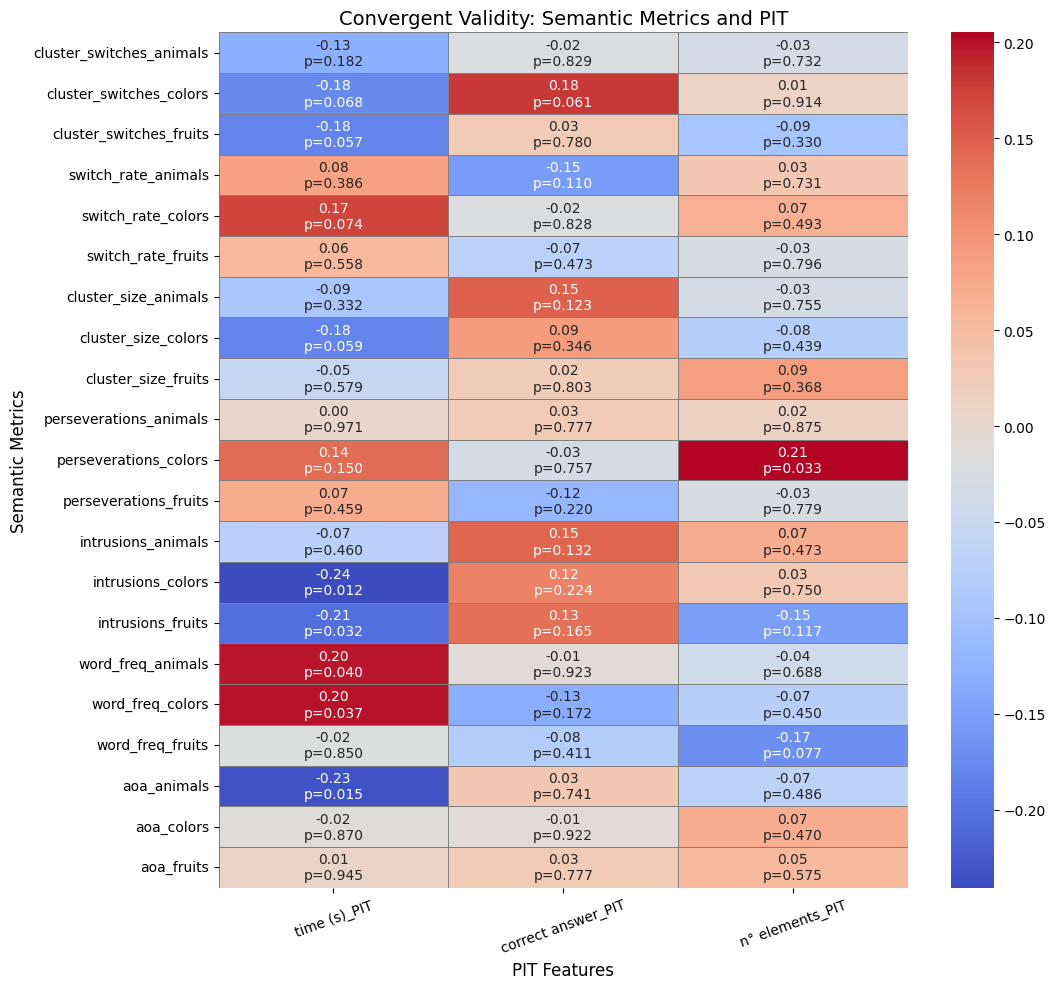

In [28]:

semantic_metric_columns = [col for col in df_wide.columns if any(
    col.startswith(prefix) for prefix in [
        'cluster_', 'switch_rate_', 'cluster_size_', 'perseverations_', 'intrusions_', 'word_freq_', 'aoa_'])]

spearman_results_cleaned = []

for sem in semantic_metric_columns:
    for pit in pit_features:
        valid_data = df_merged[[sem, pit]].dropna()
        if valid_data[sem].nunique() > 1 and valid_data[pit].nunique() > 1:
            corr, pval = spearmanr(valid_data[sem], valid_data[pit])
        else:
            corr, pval = np.nan, np.nan
        spearman_results_cleaned.append({
            'Semantic Feature': sem,
            'PIT Feature': pit,
            'Spearman Correlation': corr,
            'p-value': pval
        })

numeric_matrix_cleaned = pd.DataFrame(index=semantic_metric_columns, columns=pit_features, dtype=float)
annotation_matrix_cleaned = pd.DataFrame(index=semantic_metric_columns, columns=pit_features, dtype=object)

for row in spearman_results_cleaned:
    sem = row['Semantic Feature']
    pit = row['PIT Feature']
    corr = row['Spearman Correlation']
    pval = row['p-value']
    numeric_matrix_cleaned.loc[sem, pit] = corr
    if not np.isnan(corr) and not np.isnan(pval):
        annotation_matrix_cleaned.loc[sem, pit] = f"{corr:.2f}\np={pval:.3f}"
    else:
        annotation_matrix_cleaned.loc[sem, pit] = "N/A"

plt.figure(figsize=(11, 10))
sns.heatmap(numeric_matrix_cleaned.astype(float), annot=annotation_matrix_cleaned, fmt='', cmap='coolwarm',
            cbar=True, linewidths=0.6, linecolor='gray', mask=numeric_matrix_cleaned.isna())
plt.title("Convergent Validity: Semantic Metrics and PIT", fontsize=14)
plt.xlabel("PIT Features", fontsize=12)
plt.ylabel("Semantic Metrics", fontsize=12)
plt.xticks(rotation=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Spearman + CI: 100%|██████████| 21/21 [00:40<00:00,  1.93s/it]


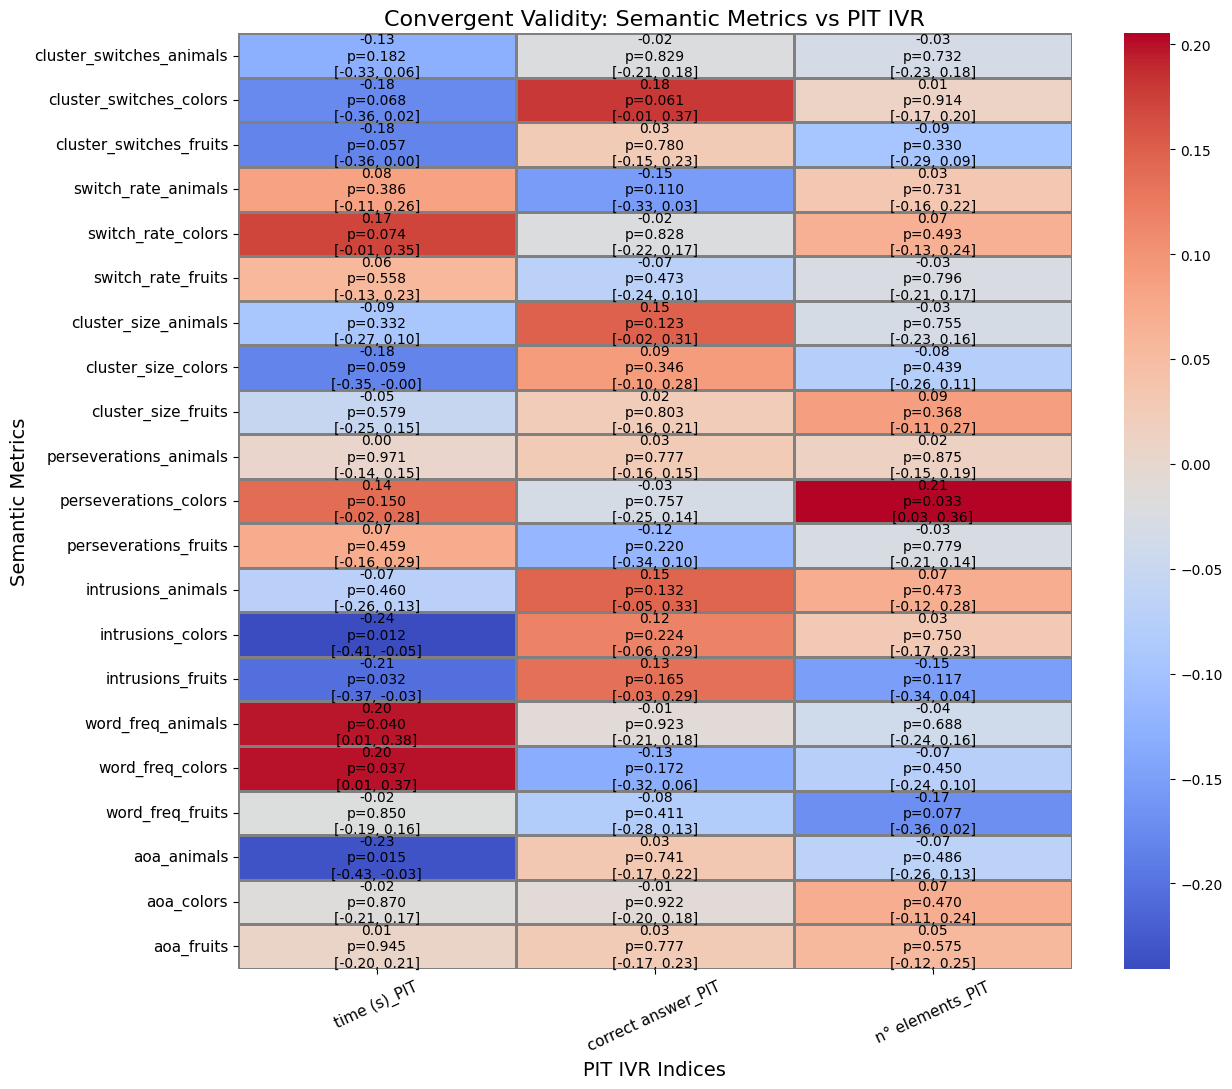

In [1]:

# Load the analysis datasets
df_wide = pd.read_csv("df_wide.csv")
df_merged = pd.read_csv("df_merged (semantic+nps).csv")

# Extract semantic metrics from the wide-format dataset
semantic_metric_columns = [col for col in df_wide.columns if any(
    col.startswith(prefix) for prefix in [
        'cluster_', 'switch_rate_', 'cluster_size_', 
        'perseverations_', 'intrusions_', 'word_freq_', 'aoa_'])]

# Select the PIT outcome variables
pit_features = ["time (s)_PIT", "correct answer_PIT", "n° elements_PIT"]

# Define bootstrap parameters
n_bootstrap = 1000
ci_lower = 2.5
ci_upper = 97.5

# Initialize result matrices
numeric_matrix = pd.DataFrame(index=semantic_metric_columns, columns=pit_features, dtype=float)
annotation_matrix = pd.DataFrame(index=semantic_metric_columns, columns=pit_features, dtype=object)
spearman_results_cleaned = []

# Estimate Spearman correlations and bootstrap confidence intervals
for sem in tqdm(semantic_metric_columns, desc="Spearman + CI"):
    for pit in pit_features:
        valid_data = df_merged[[sem, pit]].dropna()
        
        if valid_data[sem].nunique() > 1 and valid_data[pit].nunique() > 1:
            # Estimate the observed Spearman correlation
            corr, pval = spearmanr(valid_data[sem], valid_data[pit])

            # Bootstrap the confidence interval
            corr_values = []
            for _ in range(n_bootstrap):
                sample = valid_data.sample(n=len(valid_data), replace=True)
                if sample[sem].nunique() > 1 and sample[pit].nunique() > 1:
                    boot_corr, _ = spearmanr(sample[sem], sample[pit])
                    if not np.isnan(boot_corr):
                        corr_values.append(boot_corr)

            if len(corr_values) > 0:
                ci_low = np.percentile(corr_values, ci_lower)
                ci_high = np.percentile(corr_values, ci_upper)
            else:
                ci_low = ci_high = np.nan
        else:
            corr = pval = ci_low = ci_high = np.nan

        # Store the correlation results
        numeric_matrix.loc[sem, pit] = corr
        if not np.isnan(corr):
            annotation_matrix.loc[sem, pit] = f"{corr:.2f}\np={pval:.3f}\n[{ci_low:.2f}, {ci_high:.2f}]"
        else:
            annotation_matrix.loc[sem, pit] = "N/A"

        spearman_results_cleaned.append({
            'Semantic Feature': sem,
            'PIT Feature': pit,
            'Spearman Correlation': corr,
            'p-value': pval,
            '95% CI Lower': ci_low,
            '95% CI Upper': ci_high
        })

# Visualize the correlation matrix as a heatmap
annotation_matrix = annotation_matrix.astype(str).fillna("N/A")
numeric_matrix = numeric_matrix.astype(float)

plt.figure(figsize=(13, 11)) 
sns.heatmap(
    numeric_matrix,
    annot=annotation_matrix.values,
    fmt='',
    cmap='coolwarm',
    cbar=True,
    linewidths=1.0,
    linecolor='gray',
    mask=numeric_matrix.isna(),
    annot_kws={"fontsize": 10, "color": "black", "va": "center"}
)
plt.title("Convergent Validity: Semantic Metrics vs PIT IVR", fontsize=16)
plt.xlabel("PIT IVR Indices", fontsize=14)
plt.ylabel("Semantic Metrics", fontsize=14)
plt.xticks(rotation=25, fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()
